In [3]:
#Program  5 Build a simple Artificial Neural Network (ANN) with configurable activation and loss functions. 
#Train the network using activation and loss functions.
import numpy as np 
# XOR Dataset 
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]) 
y = np.array([[0], [1], [1], [0]]) 
class SimpleNN: 
    def __init__(self, learning_rate=0.1, activation='sigmoid', loss_type='mse'): 
         
        np.random.seed(42) 
         
        self.W1 = np.random.randn(2, 4) * 0.5 
        self.b1 = np.zeros((1, 4)) 
        self.W2 = np.random.randn(4, 1) * 0.5 
        self.b2 = np.zeros((1, 1)) 
         
        self.lr = learning_rate 
        self.activation_name = activation 
        self.loss_type = loss_type 
        self.losses = [] 
         
    def activation(self, x, derivative=False): 
        if self.activation_name == 'sigmoid': 
            if derivative: 
                return x * (1 - x) 
            return 1 / (1 + np.exp(-x)) 
         
        elif self.activation_name == 'tanh': 
            if derivative: 
                return 1 - x**2 
            return np.tanh(x) 
         
        elif self.activation_name == 'relu': 
            if derivative: 
                return (x > 0).astype(float) 
            return np.maximum(0, x) 
 
             
    def compute_loss(self, output, y): 
        m = y.shape[0] 
         
        if self.loss_type == 'mse': 
            return np.mean((output - y) ** 2) 
         
        elif self.loss_type == 'bce':  # Binary Cross Entropy 
            epsilon = 1e-8 
            return -np.mean(y * np.log(output + epsilon) +  
                            (1 - y) * np.log(1 - output + epsilon)) 
 
    def loss_derivative(self, output, y): 
        m = y.shape[0] 
         
        if self.loss_type == 'mse': 
            return (output - y) 
         
        elif self.loss_type == 'bce': 
            epsilon = 1e-8 
            return (output - y) / ((output + epsilon) * (1 - output + epsilon)) 
 
    
     
    def forward(self, X): 
        self.z1 = np.dot(X, self.W1) + self.b1 
        self.a1 = self.activation(self.z1) 
         
        self.z2 = np.dot(self.a1, self.W2) + self.b2 
        self.a2 = self.activation(self.z2) 
         
        return self.a2 
 
     
    def backward(self, X, y, output): 
        m = X.shape[0] 
         
        dz2 = self.loss_derivative(output, y) * self.activation(self.a2, derivative=True) 
        dW2 = (1/m) * np.dot(self.a1.T, dz2) 
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True) 
         
        da1 = np.dot(dz2, self.W2.T) 
        dz1 = da1 * self.activation(self.a1, derivative=True) 
        dW1 = (1/m) * np.dot(X.T, dz1) 
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True) 
         
        self.W2 -= self.lr * dW2 
        self.b2 -= self.lr * db2 
        self.W1 -= self.lr * dW1 
        self.b1 -= self.lr * db1 
 
     
    def train(self, X, y, epochs=1000, print_every=200): 
        for i in range(epochs): 
             
            output = self.forward(X) 
            loss = self.compute_loss(output, y) 
            self.losses.append(loss) 
             
            self.backward(X, y, output) 
             
            if i % print_every == 0: 
                print(f"  Epoch {i:4d}, Loss: {loss:.6f}") 
 
     
    def predict(self, X): 
        return (self.forward(X) > 0.5).astype(int) 
     
    def accuracy(self, X, y): 
        return np.mean(self.predict(X) == y) * 100 
 
def test_learning_rates(): 
    learning_rates = [0.01, 0.1, 1.0] 
    for lr in learning_rates: 
        print(f"\n=== Learning Rate: {lr} (Loss = MSE) ===") 
        nn = SimpleNN(learning_rate=lr, activation='sigmoid', loss_type='mse') 
        nn.train(X, y, epochs=500, print_every=100) 
        print(f"  Final Loss: {nn.losses[-1]:.6f}") 
        print(f"  Accuracy: {nn.accuracy(X, y):.1f}%") 
def test_loss_functions(): 
    losses = ['mse', 'bce'] 
    for loss_type in losses: 
        print(f"\n=== Loss Function: {loss_type.upper()} ===") 
        nn = SimpleNN(learning_rate=0.1, activation='sigmoid', loss_type=loss_type) 
        nn.train(X, y, epochs=500, print_every=100) 
        print(f"  Final Loss: {nn.losses[-1]:.6f}") 
        print(f"  Accuracy: {nn.accuracy(X, y):.1f}%") 
test_learning_rates() 
test_loss_functions() 


=== Learning Rate: 0.01 (Loss = MSE) ===
  Epoch    0, Loss: 0.255675
  Epoch  100, Loss: 0.254381
  Epoch  200, Loss: 0.253395
  Epoch  300, Loss: 0.252647
  Epoch  400, Loss: 0.252081
  Final Loss: 0.251658
  Accuracy: 50.0%

=== Learning Rate: 0.1 (Loss = MSE) ===
  Epoch    0, Loss: 0.255675
  Epoch  100, Loss: 0.250662
  Epoch  200, Loss: 0.250364
  Epoch  300, Loss: 0.250333
  Epoch  400, Loss: 0.250317
  Final Loss: 0.250303
  Accuracy: 75.0%

=== Learning Rate: 1.0 (Loss = MSE) ===
  Epoch    0, Loss: 0.255675
  Epoch  100, Loss: 0.250239
  Epoch  200, Loss: 0.250144
  Epoch  300, Loss: 0.250076
  Epoch  400, Loss: 0.250022
  Final Loss: 0.249977
  Accuracy: 50.0%

=== Loss Function: MSE ===
  Epoch    0, Loss: 0.255675
  Epoch  100, Loss: 0.250662
  Epoch  200, Loss: 0.250364
  Epoch  300, Loss: 0.250333
  Epoch  400, Loss: 0.250317
  Final Loss: 0.250303
  Accuracy: 75.0%

=== Loss Function: BCE ===
  Epoch    0, Loss: 0.704555
  Epoch  100, Loss: 0.693783
  Epoch  200, Loss

Training with different learning rates...


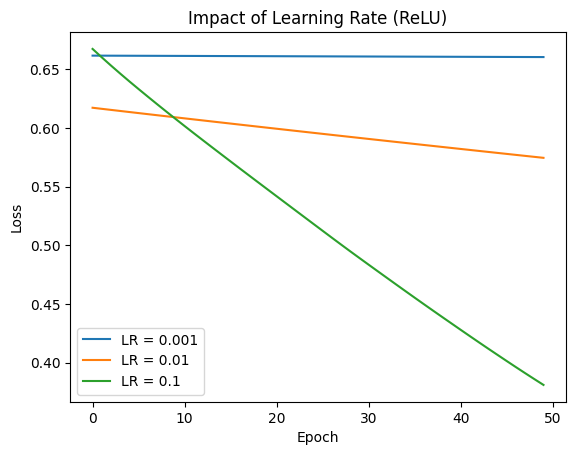

Training with different activation functions...


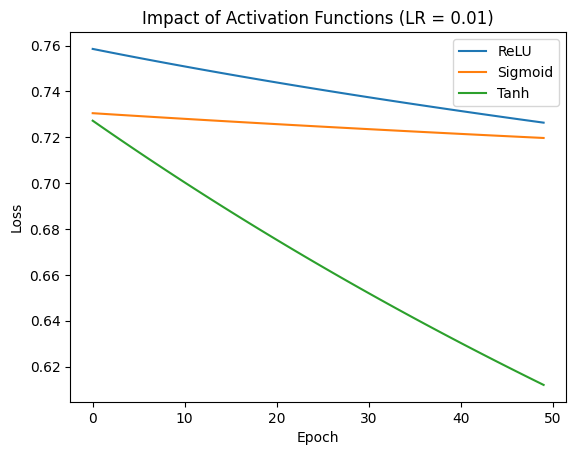

In [10]:
#Program-4 Implement a simple feedforward neural network to demonstrate the impact of different learning 
#rates and activation functions.
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
X = torch.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).float().view(-1, 1)

class SimpleNN(nn.Module):
    def __init__(self, activation_fn):
        super(SimpleNN, self).__init__()
        
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)
        self.activation = activation_fn
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))  
        return x

def train_model(learning_rate, activation_fn, epochs=50):
    
    model = SimpleNN(activation_fn)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    losses = []
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        outputs = model(X)
        loss = criterion(outputs, y)
        
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
    return losses

print("Training with different learning rates...")

lr_small = 0.001
lr_medium = 0.01
lr_large = 0.1

loss_small = train_model(lr_small, nn.ReLU())
loss_medium = train_model(lr_medium, nn.ReLU())
loss_large = train_model(lr_large, nn.ReLU())

plt.figure()
plt.plot(loss_small, label="LR = 0.001")
plt.plot(loss_medium, label="LR = 0.01")
plt.plot(loss_large, label="LR = 0.1")
plt.legend()
plt.title("Impact of Learning Rate (ReLU)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("Training with different activation functions...")

loss_relu = train_model(0.01, nn.ReLU())
loss_sigmoid = train_model(0.01, nn.Sigmoid())
loss_tanh = train_model(0.01, nn.Tanh())

plt.figure()
plt.plot(loss_relu, label="ReLU")
plt.plot(loss_sigmoid, label="Sigmoid")
plt.plot(loss_tanh, label="Tanh")
plt.legend()
plt.title("Impact of Activation Functions (LR = 0.01)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



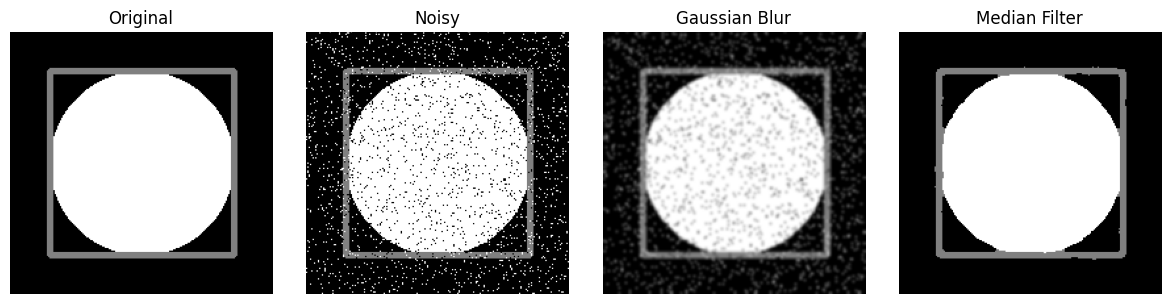

Gaussian PSNR: 31.45 dB
Median PSNR: 76.52 dB


In [12]:
#Program 3Write a Python program to apply various image smoothing techniques on a noisy image using 
#Gaussian Blur and Median Filter and compare the effects.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img, (100, 100), 70, 255, -1)
cv2.rectangle(img, (30, 30), (170, 170), 128, 3)

noisy = img.copy()
salt_pepper = np.random.random(img.shape)
noisy[salt_pepper < 0.05] = 0        # Pepper noise
noisy[salt_pepper > 0.95] = 255      # Salt noise

gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)


plt.figure(figsize=(12, 3))
titles = ['Original', 'Noisy', 'Gaussian Blur', 'Median Filter']
images = [img, noisy, gaussian, median]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


def psnr(original, processed):
    mse = np.mean((original - processed) ** 2)
    return 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

print(f"Gaussian PSNR: {psnr(img, gaussian):.2f} dB")
print(f"Median PSNR: {psnr(img, median):.2f} dB")



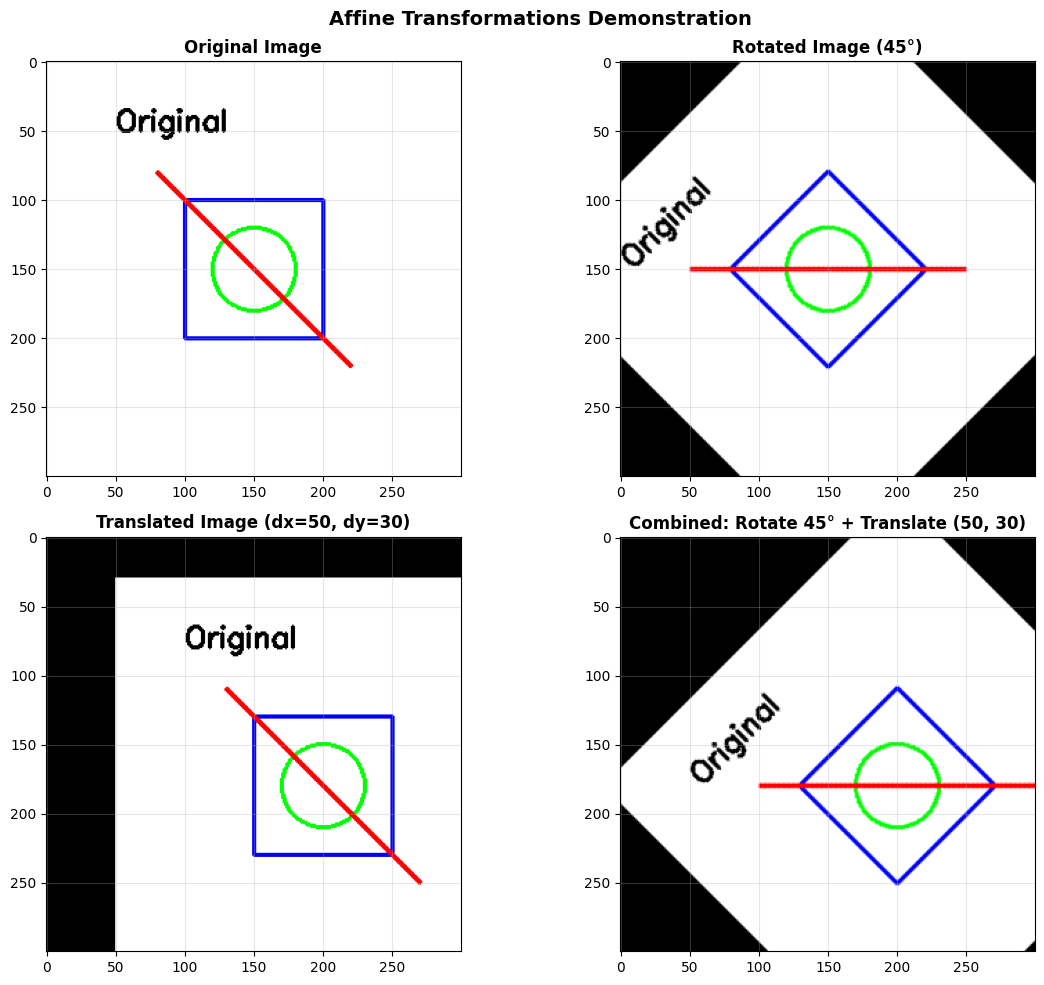


=== Transformation Matrices ===

Rotation Matrix (45°):
[[  0.70710678   0.70710678 -62.13203436]
 [ -0.70710678   0.70710678 150.        ]]

Rotation angle: 45°, Center: (150, 150)

Translation Matrix:
[[ 1.  0. 50.]
 [ 0.  1. 30.]]
Translation: dx=50, dy=30

Combined Transformation Matrix:
[[  0.70710677  -0.70710677 200.        ]
 [  0.70710677   0.70710677 -32.132034  ]]


In [18]:
#Program-2 Write a Python program to rotate and translate a given image using affine transformation. Display 
#the original image, rotated image, translated image, and combined rotated and translated image. 
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_sample_image():
    """Create a sample image with shapes """
    # Create a blank white image
    img = np.ones((300, 300, 3), dtype=np.uint8) * 255
    # Rectangle
    cv2.rectangle(img, (100, 100), (200, 200), (255, 0, 0), 2)
    # Circle
    cv2.circle(img, (150, 150), 30, (0, 255, 0), 2)
    # Line
    cv2.line(img, (80, 80), (220, 220), (0, 0, 255), 2)
    # Text
    cv2.putText(img, 'Original', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
    return img

def rotate_image(image, angle):
    """Rotate image by given angle"""
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (width, height))
    return rotated, rotation_matrix

def translate_image(image, tx, ty):
    """Translate image by tx in x-direction and ty in y-direction"""
    height, width = image.shape[:2]
    translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    translated = cv2.warpAffine(image, translation_matrix, (width, height))
    return translated, translation_matrix

def rotate_and_translate(image, angle, tx, ty):
    """Combine rotation and translation"""
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotation_matrix[0, 2] += tx
    rotation_matrix[1, 2] += ty
    transformed = cv2.warpAffine(image, rotation_matrix, (width, height))
    return transformed

def display_transformations():
    original = create_sample_image()
    rotation_angle = 45  # degrees
    translation_x = 50
    translation_y = 30
    rotated, rot_matrix = rotate_image(original, rotation_angle)
    translated, trans_matrix = translate_image(original, translation_x, translation_y)
    combined = rotate_and_translate(original, rotation_angle, translation_x, translation_y)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('on')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title(f'Rotated Image ({rotation_angle}°)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('on')
    axes[0, 1].grid(True, alpha=0.3)
    axes[1, 0].imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title(f'Translated Image (dx={translation_x}, dy={translation_y})', fontsize=12, fontweight='bold')
    axes[1, 0].axis('on')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 1].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title(f'Combined: Rotate {rotation_angle}° + Translate ({translation_x}, {translation_y})', 
                         fontsize=12, fontweight='bold')
    axes[1, 1].axis('on')
    axes[1, 1].grid(True, alpha=0.3)
    plt.suptitle('Affine Transformations Demonstration', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n=== Transformation Matrices ===")
    print("\nRotation Matrix (45°):")
    print(rot_matrix)
    print(f"\nRotation angle: {rotation_angle}°, Center: (150, 150)")
    print("\nTranslation Matrix:")
    print(trans_matrix)
    print(f"Translation: dx={translation_x}, dy={translation_y}")
    print("\nCombined Transformation Matrix:")
    combined_matrix = np.float32([[np.cos(np.radians(rotation_angle)), 
                                   -np.sin(np.radians(rotation_angle)), 
                                   translation_x + (1-np.cos(np.radians(rotation_angle)))*150 + 
                                   np.sin(np.radians(rotation_angle))*150],
                                  [np.sin(np.radians(rotation_angle)), 
                                   np.cos(np.radians(rotation_angle)),
                                   translation_y - np.sin(np.radians(rotation_angle))*150 + (1-np.cos(np.radians(rotation_angle)))*150]])
    print(combined_matrix)
def main():
    try:
        display_transformations()
     
    except Exception as e:
        print(f"An error occurred: {e}")
        
if __name__ == "__main__":
    main()

    

[[[133 131 130]
  [133 131 130]
  [133 131 130]
  ...
  [135 131 128]
  [138 131 127]
  [188 182 175]]

 [[133 131 130]
  [133 131 130]
  [133 131 130]
  ...
  [135 131 128]
  [138 131 127]
  [188 182 175]]

 [[133 131 130]
  [133 131 130]
  [133 131 130]
  ...
  [135 131 128]
  [138 131 127]
  [188 182 175]]

 ...

 [[155  33  26]
  [155  33  26]
  [155  33  26]
  ...
  [135 131 128]
  [134 128 121]
  [189 181 173]]

 [[147  37  26]
  [147  37  26]
  [147  37  26]
  ...
  [134 128 121]
  [140 129 121]
  [194 181 172]]

 [[211 108  95]
  [211 108  95]
  [211 108  95]
  ...
  [188 180 172]
  [191 179 170]
  [216 202 191]]]
Image shape: (1024, 1024, 3)
Image dtype: uint8
Min pixel value: 0, Max pixel value: 248


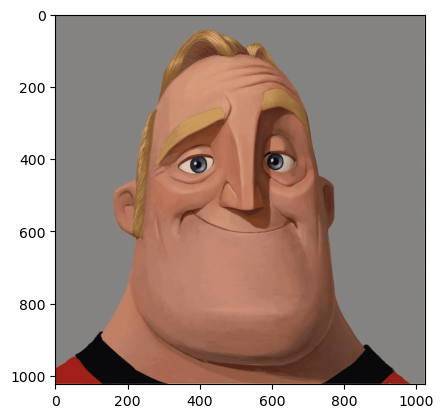

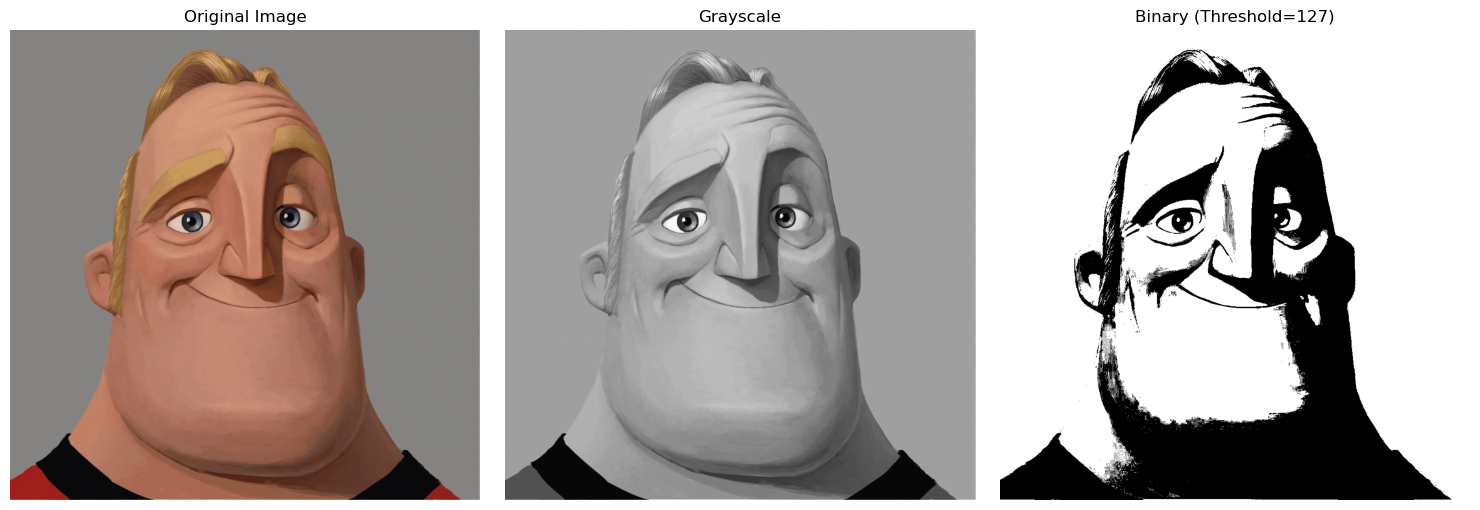

Threshold: 127
White pixels: 764266
Black pixels: 284310
Percentage white: 72.9%


In [1]:
#Program-1 Write a Python program to convert a given color image to grayscale and then to binary using 
#thresholding. Display the original image, grayscale image, and binary image. 
import matplotlib.pyplot as plt
import numpy as np
try:
    x = plt.imread(r'1/inc.jpeg')
    print(x)
    plt.imshow(x)
    print(f"Image shape: {x.shape}")
    print(f"Image dtype: {x.dtype}")
    print(f"Min pixel value: {x.min()}, Max pixel value: {x.max()}")
except FileNotFoundError:
    print("File not found at specified path!")
# Convert to grayscale
red = x[:, :, 0]
green = x[:, :, 1]
blue = x[:, :, 2]
gray = 0.299 * red + 0.587 * green + 0.114 * blue
gray_uint8 = gray.astype(np.uint8)

threshold = 127  
binary = np.where(gray_uint8 > threshold, 255, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gray_uint8, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(binary, cmap='gray')
axes[2].set_title(f'Binary (Threshold={threshold})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Threshold: {threshold}")
print(f"White pixels: {np.sum(binary == 255)}")
print(f"Black pixels: {np.sum(binary == 0)}")
print(f"Percentage white: {np.sum(binary == 255)/binary.size*100:.1f}%")